In [1]:
from google.colab import files

uploaded = files.upload()

Saving Cognevance_Level2_Sales_Forecasting_Dataset.csv to Cognevance_Level2_Sales_Forecasting_Dataset (1).csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Cognevance_Level2_Sales_Forecasting_Dataset.csv")

In [4]:
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 2192
Columns: 8


In [5]:
df.head()

,Date,Sales,Orders,Quantity,Profit,Year,Month,Month_Name
0,2019-01-01,877.73,51,67,151.97,2019,1,January
1,2019-01-02,811.35,24,30,73.85,2019,1,January
2,2019-01-03,901.26,37,54,148.28,2019,1,January
3,2019-01-04,1001.00,30,40,103.05,2019,1,January
4,2019-01-05,811.17,38,55,148.47,2019,1,January


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2192 non-null   object 
 1   Sales       2192 non-null   float64
 2   Orders      2192 non-null   int64  
 3   Quantity    2192 non-null   int64  
 4   Profit      2192 non-null   float64
 5   Year        2192 non-null   int64  
 6   Month       2192 non-null   int64  
 7   Month_Name  2192 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 137.1+ KB


In [7]:
df.isnull().sum()

,0
Date,0
Sales,0
Orders,0
Quantity,0
Profit,0
Year,0
Month,0
Month_Name,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2192 non-null   datetime64[ns]
 1   Sales       2192 non-null   float64       
 2   Orders      2192 non-null   int64         
 3   Quantity    2192 non-null   int64         
 4   Profit      2192 non-null   float64       
 5   Year        2192 non-null   int64         
 6   Month       2192 non-null   int64         
 7   Month_Name  2192 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 137.1+ KB


In [11]:
df.head()

,Date,Sales,Orders,Quantity,Profit,Year,Month,Month_Name
0,2019-01-01,877.73,51,67,151.97,2019,1,January
1,2019-01-02,811.35,24,30,73.85,2019,1,January
2,2019-01-03,901.26,37,54,148.28,2019,1,January
3,2019-01-04,1001.00,30,40,103.05,2019,1,January
4,2019-01-05,811.17,38,55,148.47,2019,1,January


In [12]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 3017779.63


In [13]:
average_daily_sales = df["Sales"].mean()

print("Average Daily Sales:", round(average_daily_sales, 2))

Average Daily Sales: 1376.72


In [14]:
yearly_sales = df.groupby("Year")["Sales"].sum()

print(yearly_sales)

Year
2019    379794.73
2020    427663.85
2021    481883.61
2022    528736.85
2023    575601.14
2024    624099.45
Name: Sales, dtype: float64


In [15]:
yearly_sales_df = yearly_sales.reset_index()

yearly_sales_df.columns = ["Year", "Total_Sales"]

yearly_sales_df

,Year,Total_Sales
0,2019,379794.73
1,2020,427663.85
2,2021,481883.61
3,2022,528736.85
4,2023,575601.14
5,2024,624099.45


In [16]:
best_year = yearly_sales.idxmax()
best_year_sales = yearly_sales.max()

print("Best Sales Year:", best_year)
print("Sales in Best Year:", round(best_year_sales, 2))

Best Sales Year: 2024
Sales in Best Year: 624099.45


In [17]:
lowest_year = yearly_sales.idxmin()
lowest_year_sales = yearly_sales.min()

print("Lowest Sales Year:", lowest_year)
print("Sales in Lowest Year:", round(lowest_year_sales, 2))

Lowest Sales Year: 2019
Sales in Lowest Year: 379794.73


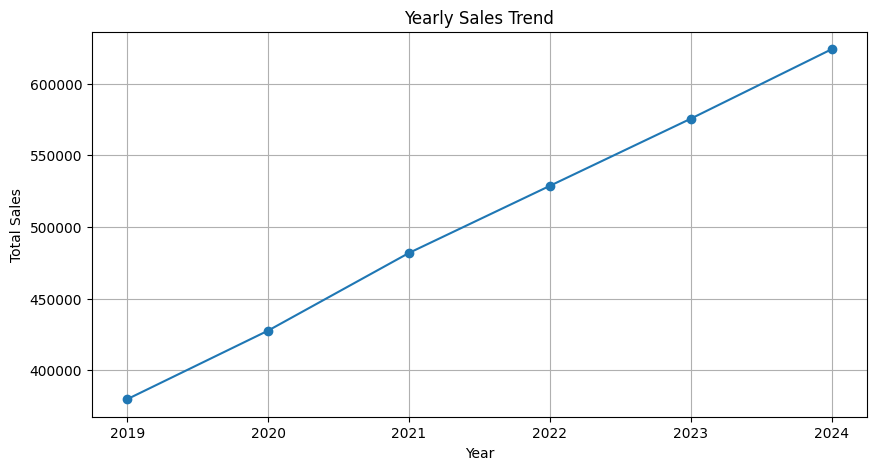

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

In [19]:
monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales)

Month
1     225057.25
2     229113.25
3     270009.22
4     266139.65
5     275969.26
6     260054.90
7     246473.64
8     237283.76
9     225160.33
10    243292.62
11    260788.85
12    278436.90
Name: Sales, dtype: float64


In [20]:
monthly_sales_df = monthly_sales.reset_index()

monthly_sales_df.columns = ["Month", "Total_Sales"]

monthly_sales_df

,Month,Total_Sales
0,1,225057.25
1,2,229113.25
2,3,270009.22
3,4,266139.65
4,5,275969.26
5,6,260054.90
6,7,246473.64
7,8,237283.76
8,9,225160.33
9,10,243292.62


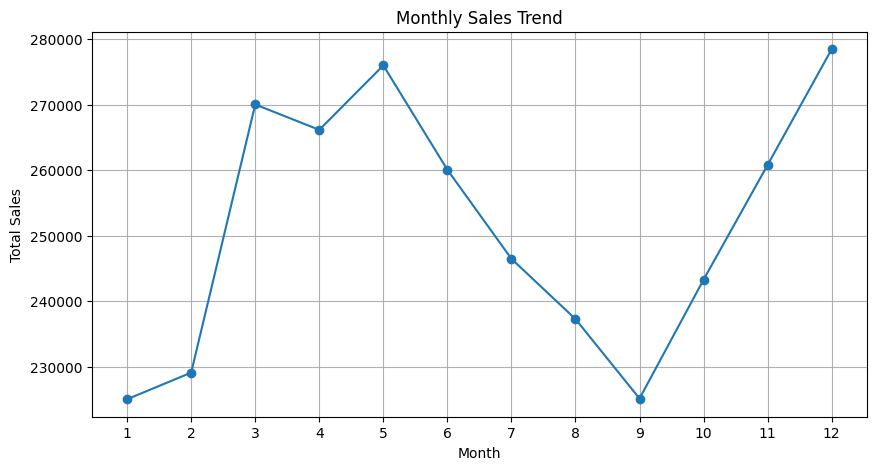

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [22]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Best Sales Month:", best_month)
print("Sales in Best Month:", round(best_month_sales, 2))

print()

print("Lowest Sales Month:", lowest_month)
print("Sales in Lowest Month:", round(lowest_month_sales, 2))

Best Sales Month: 12
Sales in Best Month: 278436.9

Lowest Sales Month: 1
Sales in Lowest Month: 225057.25


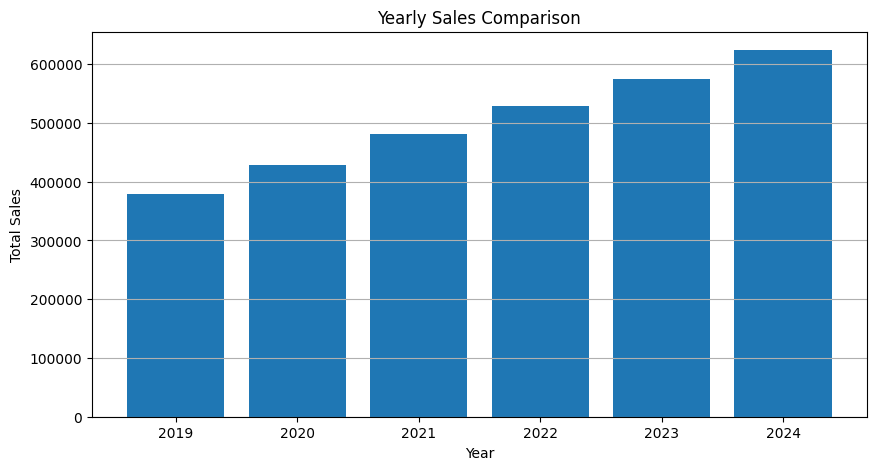

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales.index,
    yearly_sales.values
)

plt.title("Yearly Sales Comparison")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.xticks(yearly_sales.index)
plt.grid(axis="y")

plt.show()

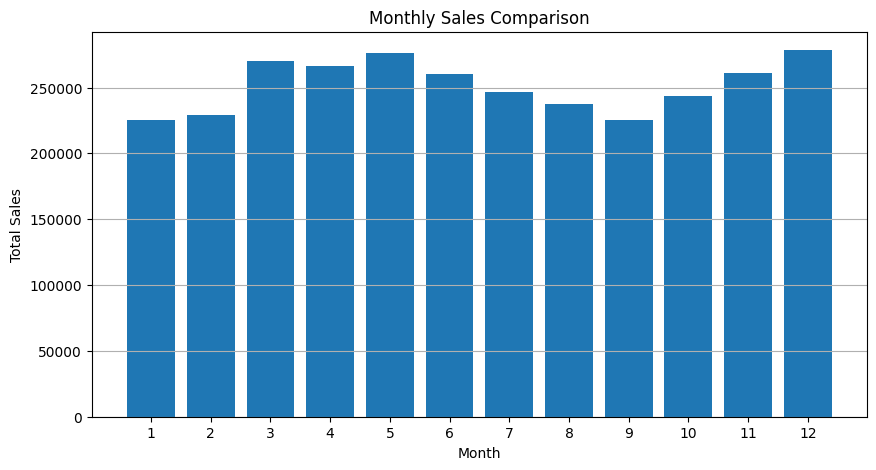

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))
plt.grid(axis="y")

plt.show()

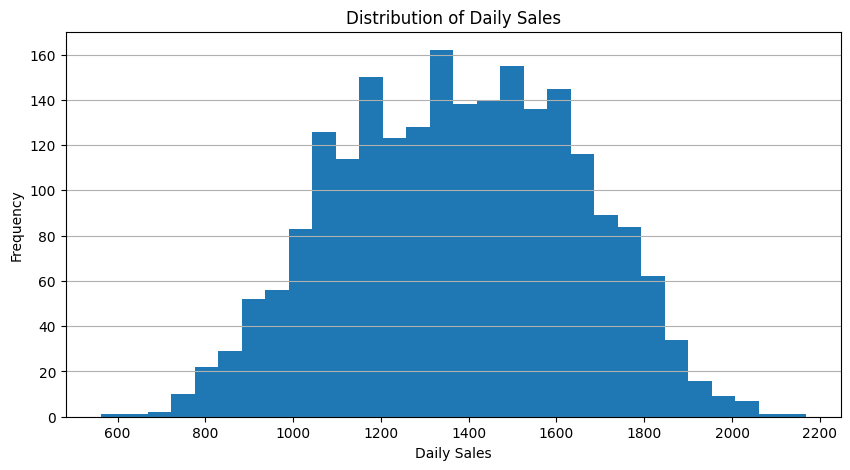

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Sales"],
    bins=30
)

plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")

plt.grid(axis="y")

plt.show()

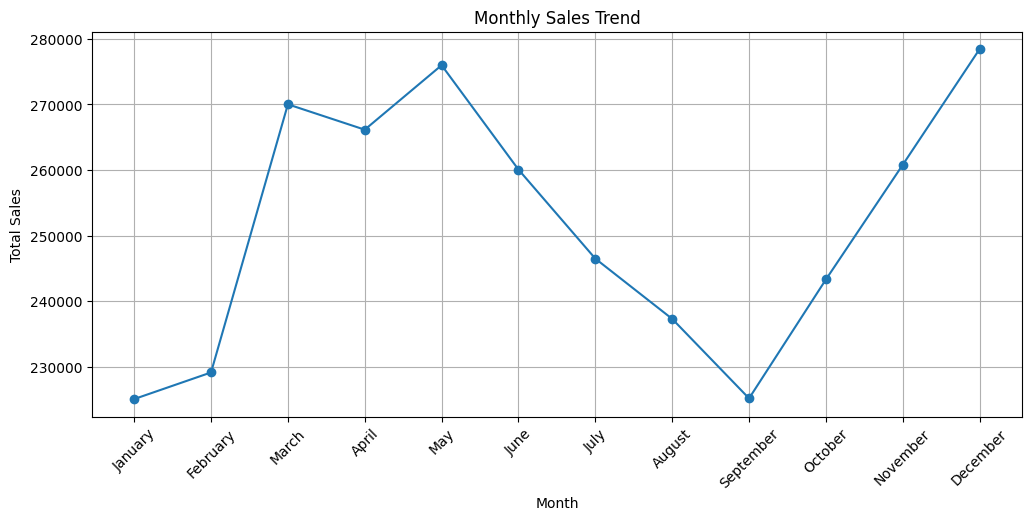

In [26]:
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.figure(figsize=(12, 5))

plt.plot(
    month_names,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [27]:
highest_daily_sales = df["Sales"].max()
lowest_daily_sales = df["Sales"].min()

print("Highest Daily Sales:", round(highest_daily_sales, 2))
print("Lowest Daily Sales:", round(lowest_daily_sales, 2))

Highest Daily Sales: 2167.39
Lowest Daily Sales: 562.3


In [28]:
monthly_data = df.groupby(
    df["Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

monthly_data.columns = ["Month", "Sales"]

monthly_data.head()

,Month,Sales
0,2019-01,26401.35
1,2019-02,27614.02
2,2019-03,34805.95
3,2019-04,34459.95
4,2019-05,35275.83


In [29]:
monthly_data.tail()

,Month,Sales
67,2024-08,49134.07
68,2024-09,47453.90
69,2024-10,50572.32
70,2024-11,53045.96
71,2024-12,56829.05


In [30]:
print("Number of months:", len(monthly_data))

Number of months: 72


In [31]:
monthly_data["Time_Index"] = range(1, len(monthly_data) + 1)

monthly_data.head()

,Month,Sales,Time_Index
0,2019-01,26401.35,1
1,2019-02,27614.02,2
2,2019-03,34805.95,3
3,2019-04,34459.95,4
4,2019-05,35275.83,5


In [32]:
monthly_data

,Month,Sales,Time_Index
0,2019-01,26401.35,1
1,2019-02,27614.02,2
2,2019-03,34805.95,3
3,2019-04,34459.95,4
4,2019-05,35275.83,5
...,...,...,...
67,2024-08,49134.07,68
68,2024-09,47453.90,69
69,2024-10,50572.32,70
70,2024-11,53045.96,71


In [33]:
train_data = monthly_data.iloc[:60]

train_data.head()

,Month,Sales,Time_Index
0,2019-01,26401.35,1
1,2019-02,27614.02,2
2,2019-03,34805.95,3
3,2019-04,34459.95,4
4,2019-05,35275.83,5


In [34]:
test_data = monthly_data.iloc[60:]

test_data.head()

,Month,Sales,Time_Index
60,2024-01,47969.71,61
61,2024-02,48417.69,62
62,2024-03,55443.79,63
63,2024-04,54548.00,64
64,2024-05,56706.88,65


In [35]:
print("Training data rows:", len(train_data))
print("Testing data rows:", len(test_data))

Training data rows: 60
Testing data rows: 12


In [36]:
X_train = train_data[["Time_Index"]]
y_train = train_data["Sales"]

X_test = test_data[["Time_Index"]]
y_test = test_data["Sales"]

In [37]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60, 1)
y_train shape: (60,)
X_test shape: (12, 1)
y_test shape: (12,)


In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
model = LinearRegression()

In [40]:
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

print(y_pred)

[50174.22329379 50511.25783894 50848.29238409 51185.32692924
 51522.36147439 51859.39601954 52196.43056469 52533.46510985
 52870.499655   53207.53420015 53544.5687453  53881.60329045]


In [42]:
comparison = pd.DataFrame({
    "Month": test_data["Month"].astype(str),
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

comparison

,Month,Actual_Sales,Predicted_Sales
60,2024-01,47969.71,50174.223294
61,2024-02,48417.69,50511.257839
62,2024-03,55443.79,50848.292384
63,2024-04,54548.00,51185.326929
64,2024-05,56706.88,51522.361474
65,2024-06,52751.82,51859.396020
66,2024-07,51226.26,52196.430565
67,2024-08,49134.07,52533.465110
68,2024-09,47453.90,52870.499655
69,2024-10,50572.32,53207.534200


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [44]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 2850.05


In [45]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Root Mean Squared Error (RMSE): 3254.0


In [46]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 4))

R² Score: -0.0078


In [47]:
print("===== MODEL PERFORMANCE =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

===== MODEL PERFORMANCE =====
MAE : 2850.05
RMSE: 3254.0
R²  : -0.0078


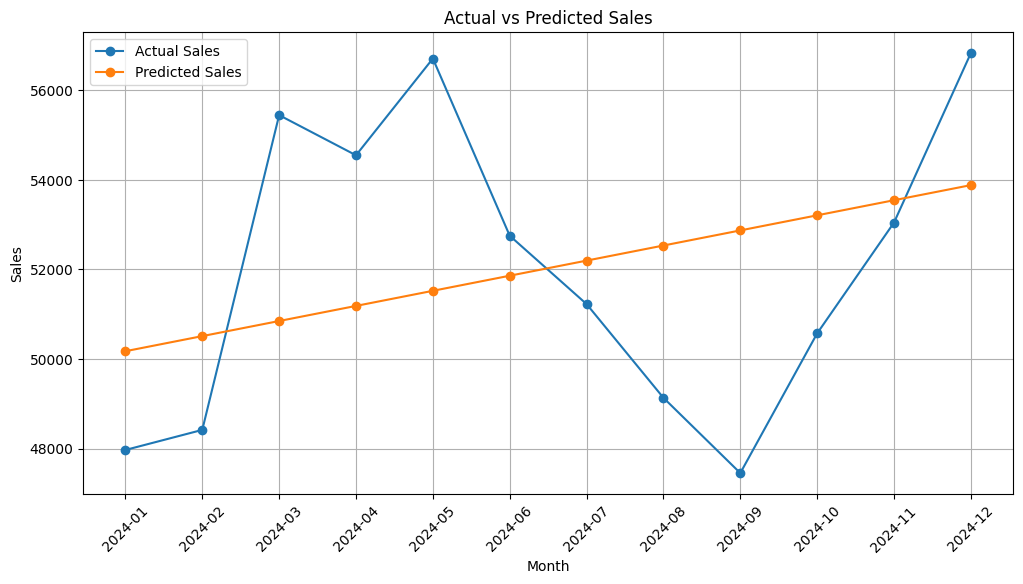

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_data["Month"].astype(str),
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_data["Month"].astype(str),
    y_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

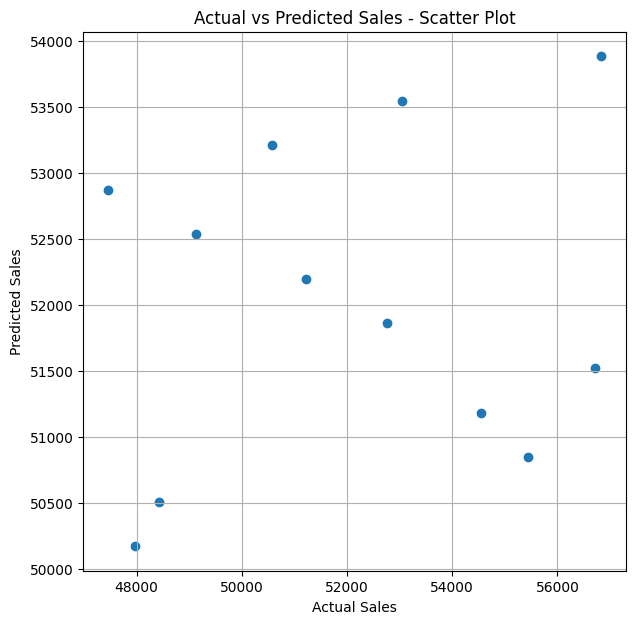

In [49]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Scatter Plot")

plt.grid(True)
plt.show()

In [50]:
comparison["Error"] = comparison["Actual_Sales"] - comparison["Predicted_Sales"]

comparison

,Month,Actual_Sales,Predicted_Sales,Error
60,2024-01,47969.71,50174.223294,-2204.513294
61,2024-02,48417.69,50511.257839,-2093.567839
62,2024-03,55443.79,50848.292384,4595.497616
63,2024-04,54548.00,51185.326929,3362.673071
64,2024-05,56706.88,51522.361474,5184.518526
65,2024-06,52751.82,51859.396020,892.423980
66,2024-07,51226.26,52196.430565,-970.170565
67,2024-08,49134.07,52533.465110,-3399.395110
68,2024-09,47453.90,52870.499655,-5416.599655
69,2024-10,50572.32,53207.534200,-2635.214200


In [51]:
mean_error = comparison["Error"].mean()

print("Average Prediction Error:", round(mean_error, 2))

Average Prediction Error: -19.63


In [52]:
future_time = np.arange(73, 85).reshape(-1, 1)

print(future_time)

[[73]
 [74]
 [75]
 [76]
 [77]
 [78]
 [79]
 [80]
 [81]
 [82]
 [83]
 [84]]


In [53]:
future_sales = model.predict(future_time)

print(future_sales)

[54218.6378356  54555.67238075 54892.70692591 55229.74147106
 55566.77601621 55903.81056136 56240.84510651 56577.87965166
 56914.91419681 57251.94874197 57588.98328712 57926.01783227]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [54]:
future_dates = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [55]:
forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Forecasted_Sales": future_sales
})

forecast_df

,Month,Forecasted_Sales
0,2025-01-01,54218.637836
1,2025-02-01,54555.672381
2,2025-03-01,54892.706926
3,2025-04-01,55229.741471
4,2025-05-01,55566.776016
5,2025-06-01,55903.810561
6,2025-07-01,56240.845107
7,2025-08-01,56577.879652
8,2025-09-01,56914.914197
9,2025-10-01,57251.948742


In [56]:
best_forecast_month = forecast_df.loc[
    forecast_df["Forecasted_Sales"].idxmax()
]

print("Highest Forecasted Month:")
print(best_forecast_month)

Highest Forecasted Month:
Month               2025-12-01 00:00:00
Forecasted_Sales           57926.017832
Name: 11, dtype: object


In [57]:
lowest_forecast_month = forecast_df.loc[
    forecast_df["Forecasted_Sales"].idxmin()
]

print("Lowest Forecasted Month:")
print(lowest_forecast_month)

Lowest Forecasted Month:
Month               2025-01-01 00:00:00
Forecasted_Sales           54218.637836
Name: 0, dtype: object


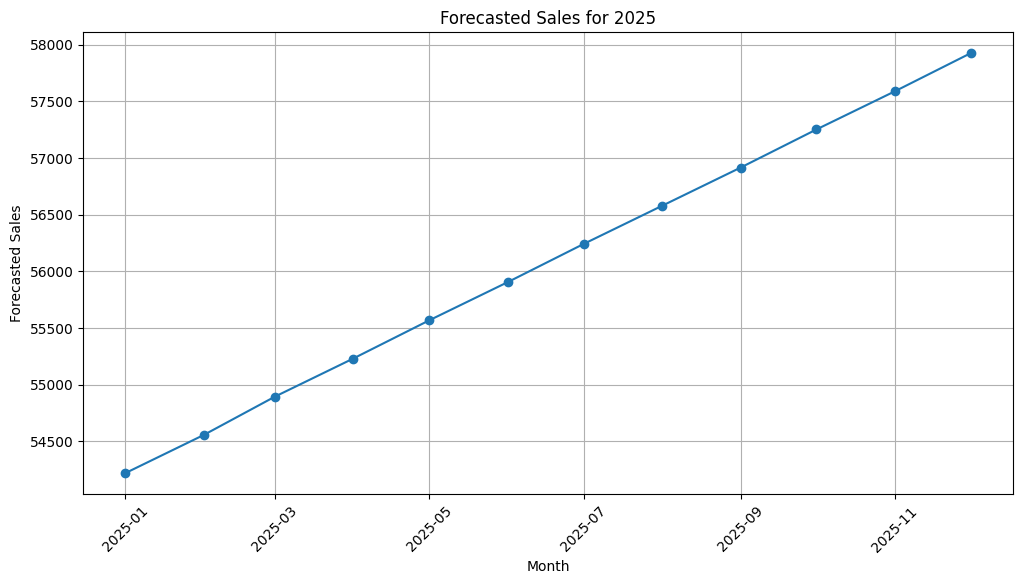

In [58]:
plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecasted_Sales"],
    marker="o"
)

plt.title("Forecasted Sales for 2025")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

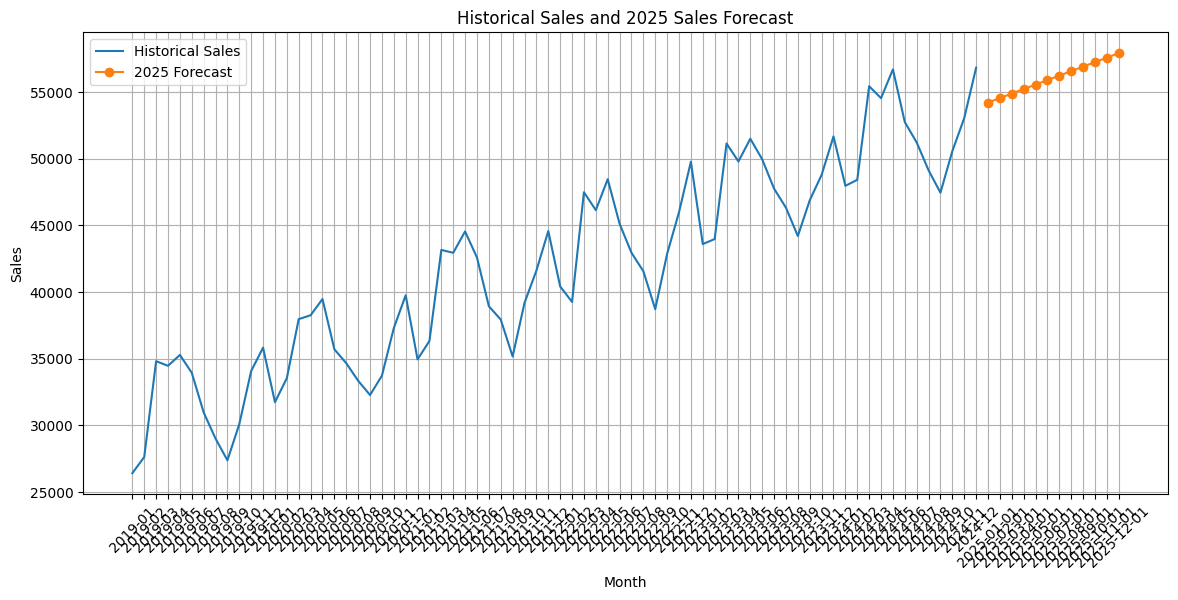

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_data["Month"].astype(str),
    monthly_data["Sales"],
    label="Historical Sales"
)

plt.plot(
    forecast_df["Month"].astype(str),
    forecast_df["Forecasted_Sales"],
    marker="o",
    label="2025 Forecast"
)

plt.title("Historical Sales and 2025 Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [60]:
print("===== SALES FORECASTING SUMMARY =====")

print("Total Historical Sales:", round(total_sales, 2))
print("Average Daily Sales:", round(average_daily_sales, 2))

print("Best Sales Year:", best_year)
print("Lowest Sales Year:", lowest_year)

print("Best Sales Month:", best_month)
print("Lowest Sales Month:", lowest_month)

print("Highest Forecasted Month:",
      best_forecast_month["Month"].strftime("%B %Y"))

print("Lowest Forecasted Month:",
      lowest_forecast_month["Month"].strftime("%B %Y"))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

===== SALES FORECASTING SUMMARY =====
Total Historical Sales: 3017779.63
Average Daily Sales: 1376.72
Best Sales Year: 2024
Lowest Sales Year: 2019
Best Sales Month: 12
Lowest Sales Month: 1
Highest Forecasted Month: December 2025
Lowest Forecasted Month: January 2025
MAE: 2850.05
RMSE: 3254.0
R² Score: -0.0078


In [61]:
total_forecast_sales = forecast_df["Forecasted_Sales"].sum()

print("Total Forecasted Sales for 2025:",
      round(total_forecast_sales, 2))

Total Forecasted Sales for 2025: 672867.93


In [62]:
average_forecast_sales = forecast_df["Forecasted_Sales"].mean()

print("Average Forecasted Monthly Sales:",
      round(average_forecast_sales, 2))

Average Forecasted Monthly Sales: 56072.33


In [63]:
sales_2024 = yearly_sales.loc[2024]

forecast_growth = (
    (total_forecast_sales - sales_2024) / sales_2024
) * 100

print("Actual Sales in 2024:", round(sales_2024, 2))
print("Forecasted Sales in 2025:", round(total_forecast_sales, 2))
print("Forecasted Growth:", round(forecast_growth, 2), "%")

Actual Sales in 2024: 624099.45
Forecasted Sales in 2025: 672867.93
Forecasted Growth: 7.81 %


In [64]:
insights = pd.DataFrame({
    "Metric": [
        "Total Historical Sales",
        "Average Daily Sales",
        "Best Sales Year",
        "Lowest Sales Year",
        "Best Sales Month",
        "Lowest Sales Month",
        "2025 Forecasted Sales",
        "2025 Forecasted Growth"
    ],
    "Value": [
        round(total_sales, 2),
        round(average_daily_sales, 2),
        best_year,
        lowest_year,
        best_month,
        lowest_month,
        round(total_forecast_sales, 2),
        f"{forecast_growth:.2f}%"
    ]
})

insights

,Metric,Value
0,Total Historical Sales,3017779.63
1,Average Daily Sales,1376.72
2,Best Sales Year,2024
3,Lowest Sales Year,2019
4,Best Sales Month,12
5,Lowest Sales Month,1
6,2025 Forecasted Sales,672867.93
7,2025 Forecasted Growth,7.81%


In [65]:
print("===== BUSINESS RECOMMENDATIONS =====")

print("1. Focus marketing and promotional activities on months "
      "with stronger sales performance.")

print("2. Analyze the reasons behind lower-performing months "
      "and consider targeted offers or campaigns.")

print("3. Use the 2025 sales forecast to support inventory "
      "and resource planning.")

print("4. Monitor actual sales against the forecast regularly "
      "to identify significant differences.")

print("5. Consider adding more business factors such as price, "
      "discounts, products, and promotions to improve future forecasts.")

===== BUSINESS RECOMMENDATIONS =====
1. Focus marketing and promotional activities on months with stronger sales performance.
2. Analyze the reasons behind lower-performing months and consider targeted offers or campaigns.
3. Use the 2025 sales forecast to support inventory and resource planning.
4. Monitor actual sales against the forecast regularly to identify significant differences.
5. Consider adding more business factors such as price, discounts, products, and promotions to improve future forecasts.


In [66]:
forecast_df.to_csv(
    "sales_forecast_2025.csv",
    index=False
)

print("Forecast file saved successfully!")

Forecast file saved successfully!


In [67]:
import os

print(os.path.exists("sales_forecast_2025.csv"))

True


In [69]:
from google.colab import files

files.download("sales_forecast_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import joblib

joblib.dump(model, "sales_forecasting_linear_regression_model.pkl")

print("Forecasting model saved successfully!")

Forecasting model saved successfully!


In [71]:
files.download("sales_forecasting_linear_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

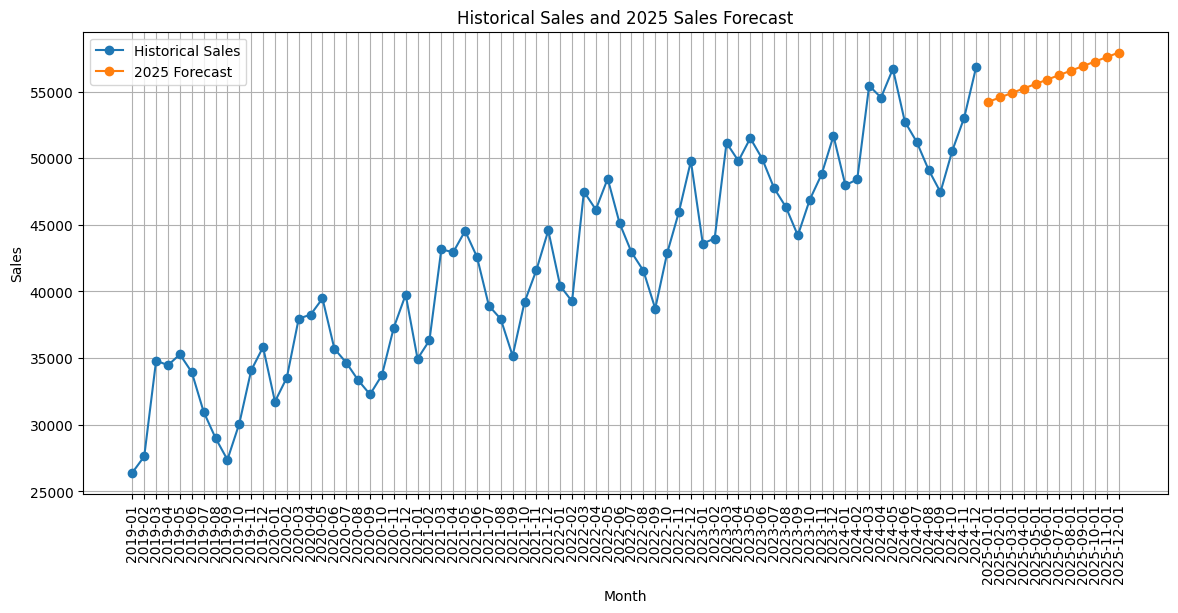

In [72]:
plt.figure(figsize=(14, 6))

# Historical sales
plt.plot(
    monthly_data["Month"].astype(str),
    monthly_data["Sales"],
    marker="o",
    label="Historical Sales"
)

# Forecasted sales
plt.plot(
    forecast_df["Month"].astype(str),
    forecast_df["Forecasted_Sales"],
    marker="o",
    label="2025 Forecast"
)

plt.title("Historical Sales and 2025 Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)
plt.legend()
plt.grid(True)

plt.show()

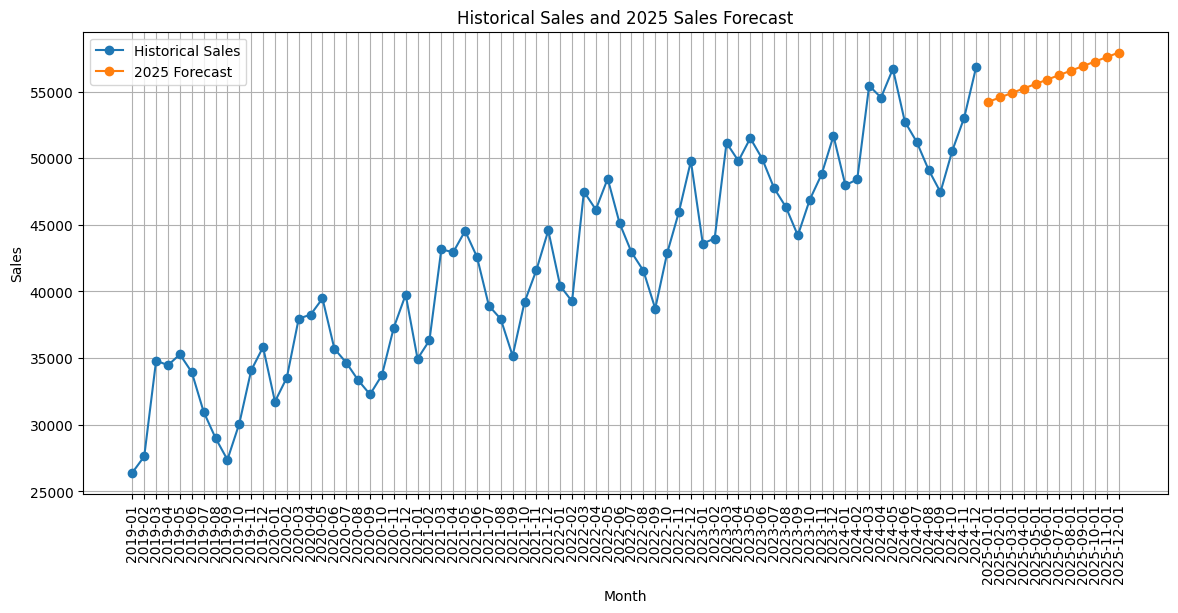

In [73]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_data["Month"].astype(str),
    monthly_data["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    forecast_df["Month"].astype(str),
    forecast_df["Forecasted_Sales"],
    marker="o",
    label="2025 Forecast"
)

plt.title("Historical Sales and 2025 Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)
plt.legend()
plt.grid(True)

plt.savefig(
    "historical_vs_forecast_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
files.download("historical_vs_forecast_2025.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
import os

files_to_check = [
    "sales_forecast_2025.csv",
    "sales_forecasting_linear_regression_model.pkl",
    "historical_vs_forecast_2025.png"
]

for file in files_to_check:
    if os.path.exists(file):
        print(file, "✓ Found")
    else:
        print(file, "✗ Missing")

sales_forecast_2025.csv ✓ Found
sales_forecasting_linear_regression_model.pkl ✓ Found
historical_vs_forecast_2025.png ✓ Found


In [76]:
print("========== FINAL PROJECT RESULTS ==========")

print("Total Historical Sales:", round(total_sales, 2))
print("Average Daily Sales:", round(average_daily_sales, 2))

print("Best Sales Year:", best_year)
print("Best Year Sales:", round(best_year_sales, 2))

print("Lowest Sales Year:", lowest_year)
print("Lowest Year Sales:", round(lowest_year_sales, 2))

print("Best Sales Month:", best_month)
print("Best Month Sales:", round(best_month_sales, 2))

print("Lowest Sales Month:", lowest_month)
print("Lowest Month Sales:", round(lowest_month_sales, 2))

print("2025 Forecasted Sales:", round(total_forecast_sales, 2))
print("Average Forecasted Monthly Sales:", round(average_forecast_sales, 2))

print("Forecasted Growth:", round(forecast_growth, 2), "%")

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

print("Highest Forecasted Month:",
      best_forecast_month["Month"].strftime("%B %Y"))

print("Lowest Forecasted Month:",
      lowest_forecast_month["Month"].strftime("%B %Y"))

========== FINAL PROJECT RESULTS ==========
Total Historical Sales: 3017779.63
Average Daily Sales: 1376.72
Best Sales Year: 2024
Best Year Sales: 624099.45
Lowest Sales Year: 2019
Lowest Year Sales: 379794.73
Best Sales Month: 12
Best Month Sales: 278436.9
Lowest Sales Month: 1
Lowest Month Sales: 225057.25
2025 Forecasted Sales: 672867.93
Average Forecasted Monthly Sales: 56072.33
Forecasted Growth: 7.81 %
MAE: 2850.05
RMSE: 3254.0
R2 Score: -0.0078
Highest Forecasted Month: December 2025
Lowest Forecasted Month: January 2025
